# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

**Method: Clustering**

The method is clustering because we have no ground truth, and i am dealing with unlabelled data. and see if the groups emerges from the features selected. we don't know what each group is yet.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [36]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

In [37]:
from huggingface_hub import HfApi
api = HfApi()
files = api.list_repo_files("FlyRank/internship-warehouse", repo_type="dataset")

r_files = [ f for f in files if "fact_content_daily_performance" in f]
for r in r_files:
  print(r)

fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parquet
fact_content_daily_performance/month=2026-03/data_0.parquet
fact_content_daily_performance/month=2026-04/data_0.parquet
fact_content_daily_performance/month=202

In [38]:
from datasets import load_dataset
import pandas as pd

cols_needed = [ 'content_hash_id', 'report_date', 'gsc_impressions', 'gsc_clicks',  'gsc_avg_position']

ds_train = load_dataset("FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-03/data_0.parquet",
    split="train", token=hf_token)
df_train = ds_train.select_columns(cols_needed).to_pandas()
del ds_train

ds_test_raw = load_dataset("FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-06/data_0.parquet",
    split="train", token=hf_token)
ds_test = ds_test_raw.shuffle(seed=42).select(range(100_000))
df_test = ds_test.select_columns(cols_needed).to_pandas()
del ds_test_raw, ds_test

cols_needed = [ 'content_hash_id', 'word_count', 'is_published']
ds_content = load_dataset("FlyRank/internship-warehouse",
    data_files="dim_content.parquet", split="train", token=hf_token)
df_content = ds_content.select_columns(cols_needed).to_pandas()
del ds_content

df_train = df_train.merge(df_content, on="content_hash_id", how="left", validate="m:1")
df_test = df_test.merge(df_content, on="content_hash_id", how="left", validate="m:1")




In [6]:
print(df_train.shape)
print(df_test.shape)

(9841378, 7)
(100000, 7)


In [39]:
df_train.describe()

,gsc_impressions,gsc_clicks,gsc_avg_position,word_count
count,9.841378e+06,9.841378e+06,3.611061e+06,6.518014e+06
mean,2.851812e+01,8.350782e-02,1.582665e+01,2.373459e+03
std,1.559266e+02,7.814341e-01,1.985603e+01,1.244869e+03
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,3.742120e+00,1.357000e+03
50%,0.000000e+00,0.000000e+00,7.500000e+00,2.469000e+03
75%,6.000000e+00,0.000000e+00,2.020000e+01,3.033000e+03
max,4.008400e+04,2.740000e+02,4.980000e+02,2.934100e+04


In [40]:
df_test.describe()

,gsc_impressions,gsc_clicks,gsc_avg_position,word_count
count,100000.000000,100000.000000,33420.000000,72566.000000
mean,19.486220,0.077050,21.208941,2499.521663
std,160.364834,0.886466,24.271492,1129.388272
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,5.600000,1530.000000
50%,0.000000,0.000000,10.000000,2620.000000
75%,3.000000,0.000000,28.836039,3047.750000
max,20104.000000,147.000000,479.000000,29341.000000


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [41]:


df_train["CTR"] = (df_train["gsc_clicks"] / df_train["gsc_impressions"]) * 100
df_test["CTR"] = (df_test["gsc_clicks"] / df_test["gsc_impressions"]) * 100

df_train.sort_values(by=['report_date', 'content_hash_id'], ascending=True, inplace=True)

df_train["trend_direction"] = df_train.groupby("content_hash_id")["gsc_avg_position"].diff().fillna(0)
df_test["trend_direction"] = df_test.groupby("content_hash_id")["gsc_avg_position"].diff().fillna(0)

In [42]:
import numpy as np
df_train["CTR"] = df_train["CTR"].fillna(df_train['CTR'].median())
df_test["CTR"] = df_test["CTR"].fillna(df_test['CTR'].median())

df_train['word_count'] = df_train['word_count'].fillna(df_train['word_count'].median())
df_test['word_count'] = df_test['word_count'].fillna(df_test['word_count'].median())


for col in ['gsc_impressions', 'gsc_clicks', 'word_count']:
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])


df_train['trend_direction'] = np.sign(df_train['trend_direction'] * np.log1p(np.abs(df_train['trend_direction'])))
df_test['trend_direction'] = np.sign(df_test['trend_direction'] * np.log1p(np.abs(df_test['trend_direction'])))



In [43]:
df_train = df_train[(df_train['is_published'] == True) & (df_train['gsc_avg_position'] <= 100)]
df_test = df_test[(df_test['is_published'] == True) & (df_test['gsc_avg_position'] <= 100)]

                  gsc_avg_position  trend_direction  gsc_impressions  \
gsc_avg_position          1.000000         0.168499        -0.193352   
trend_direction           0.168499         1.000000         0.007899   
gsc_impressions          -0.193352         0.007899         1.000000   
gsc_clicks               -0.123783        -0.005084         0.469527   
word_count                0.012389        -0.000924         0.169190   
CTR                      -0.038490        -0.007004        -0.011188   

                  gsc_clicks  word_count       CTR  
gsc_avg_position   -0.123783    0.012389 -0.038490  
trend_direction    -0.005084   -0.000924 -0.007004  
gsc_impressions     0.469527    0.169190 -0.011188  
gsc_clicks          1.000000    0.031731  0.220164  
word_count          0.031731    1.000000 -0.037068  
CTR                 0.220164   -0.037068  1.000000  


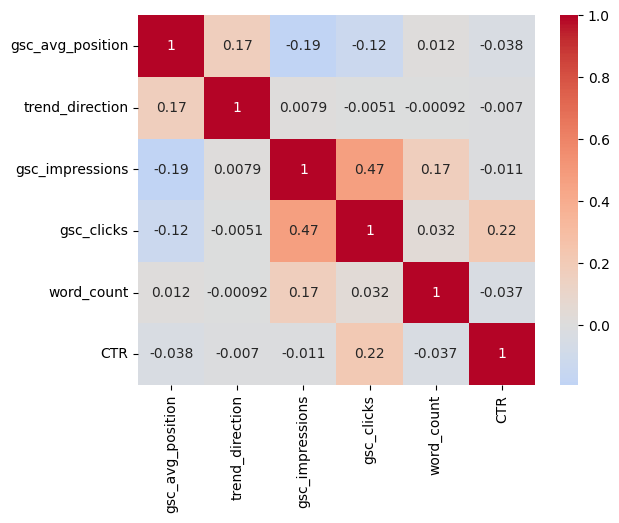

In [44]:
corr = df_train[["gsc_avg_position", "trend_direction", "gsc_impressions",
                       "gsc_clicks", "word_count", "CTR"]].corr()
print(corr)

# visually, a heatmap makes it easier to eyeball at a glance:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

In [49]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
scaler = RobustScaler()
feature_cols = ["gsc_impressions", "gsc_clicks", "word_count", "CTR", "trend_direction"]


df_train_k = df_train[feature_cols]
df_test_k = df_test[feature_cols]
X_train_scaled = scaler.fit_transform(df_train_k).astype(np.float32)
X_test_scaled = scaler.transform(df_test_k).astype(np.float32)


sample_idx = np.random.RandomState(42).choice(len(X_train_scaled), size=1000_000)


X_sample = X_train_scaled[sample_idx]


for k in range(2,10):
     km = KMeans(n_clusters=k,init='k-means++', n_init=20, random_state=42, max_iter=300)
     labels = km.fit_predict(X_sample)
     labels_test = km.predict(X_test_scaled)
     score = silhouette_score(X_sample, labels, sample_size=5_000, random_state=42)
     score_test = silhouette_score(X_test_scaled, labels_test, sample_size=5_000, random_state=42)
     print(f"silhouette score train at {k} clusters is: {score}")
     print(f"silhouette score test at {k} clusters is: {score_test}")



silhouette score train at 2 clusters is: 0.9237658381462097
silhouette score test at 2 clusters is: 0.9392011761665344
silhouette score train at 3 clusters is: 0.4223792850971222
silhouette score test at 3 clusters is: 0.4103337824344635
silhouette score train at 4 clusters is: 0.5159710049629211
silhouette score test at 4 clusters is: 0.5102536678314209
silhouette score train at 5 clusters is: 0.5261069536209106
silhouette score test at 5 clusters is: 0.5254355072975159
silhouette score train at 6 clusters is: 0.37540537118911743
silhouette score test at 6 clusters is: 0.3725825548171997
silhouette score train at 7 clusters is: 0.3782398998737335
silhouette score test at 7 clusters is: 0.3793919086456299
silhouette score train at 8 clusters is: 0.34441494941711426
silhouette score test at 8 clusters is: 0.4029717743396759
silhouette score train at 9 clusters is: 0.3415282368659973
silhouette score test at 9 clusters is: 0.407741904258728


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.